In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,PowerTransformer,OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Data Exploration

In [2]:
file_paths = [
    "/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_1.csv",
    "/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_10.csv",
     "/kaggle/input/datasets/vigneshvenkateswaran/bot-iot/data_60.csv"
]

dfs = []
target_size = 500000  

for path in file_paths:
    df = pd.read_csv(path)
    

    if "category" in df.columns:
        df = df[df["category"] != "Normal"]
    
    
    df = df.head(target_size)
    

    cols_to_drop = ["pkSeqID", "stime", "ltime", "seq"]
    for col in cols_to_drop:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)
    
    dfs.append(df)


df = pd.concat(dfs, ignore_index=True)
print("Merged dataset shape:", df.shape)
print(df["category"].value_counts())




/tmp/ipykernel_17/1899709718.py:11: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)
/tmp/ipykernel_17/1899709718.py:11: DtypeWarning: Columns (5,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path)


Merged dataset shape: (1500000, 31)
category
Reconnaissance    500000
DoS               500000
DDoS              500000
Name: count, dtype: int64


In [3]:
#shuffle
df = df.sample(frac=1).reset_index(drop=True)
df.head(10)

,flgs,proto,saddr,sport,daddr,dport,pkts,bytes,state,dur,...,spkts,dpkts,sbytes,dbytes,rate,srate,drate,attack,category,subcategory
0,e s,tcp,192.168.100.150,22766.0,192.168.100.6,80.0,5,676,RST,56.268391,...,4,1,616,60,0.071088,0.053316,0.00000,1,DoS,TCP
1,e,udp,192.168.100.147,64782,192.168.100.3,80,13,780,INT,16.572721,...,13,0,780,0,0.724081,0.724081,0.00000,1,DDoS,UDP
2,e g,tcp,192.168.100.147,37834.0,192.168.100.3,80.0,9,822,RST,49.602650,...,6,3,642,180,0.161282,0.100801,0.04032,1,DoS,TCP
3,e,udp,192.168.100.148,1680,192.168.100.3,80,11,660,INT,14.135907,...,11,0,660,0,0.707418,0.707418,0.00000,1,DDoS,UDP
4,e,udp,192.168.100.148,28004,192.168.100.3,80,10,600,INT,15.589787,...,10,0,600,0,0.577301,0.577301,0.00000,1,DDoS,UDP
5,e,udp,192.168.100.147,41075,192.168.100.3,80,12,720,INT,20.374979,...,12,0,720,0,0.539878,0.539878,0.00000,1,DDoS,UDP
6,e,udp,192.168.100.147,56501,192.168.100.3,80,11,660,INT,15.309672,...,11,0,660,0,0.653182,0.653182,0.00000,1,DDoS,UDP
7,e s,tcp,192.168.100.148,26952.0,192.168.100.5,80.0,3,462,REQ,40.352631,...,3,0,462,0,0.049563,0.049563,0.00000,1,DoS,TCP
8,e,udp,192.168.100.149,21525,192.168.100.3,80,10,600,INT,20.833794,...,10,0,600,0,0.431990,0.431990,0.00000,1,DDoS,UDP
9,e,tcp,192.168.100.148,10527.0,192.168.100.3,8236.0,2,120,RST,0.000050,...,1,1,60,60,20000.000000,0.000000,0.00000,1,Reconnaissance,Service_Scan


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pkts,1500000.0,5.903823,10.278016,1.0,2.000000,5.000000,9.000000,4.879000e+03
bytes,1500000.0,511.789559,5759.555879,60.0,120.000000,522.000000,660.000000,2.536017e+06
dur,1500000.0,20.698602,33.103954,0.0,0.028176,15.586910,38.349766,1.716233e+03
mean,1500000.0,1.197912,1.605446,0.0,0.000142,0.037325,2.869080,4.878934e+00
stddev,1500000.0,0.463678,0.690166,0.0,0.000000,0.008630,1.021309,2.499505e+00
smac,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dmac,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sum,1500000.0,3.924058,5.230167,0.0,0.000143,0.048372,10.590330,4.583837e+01
min,1500000.0,0.581048,1.104405,0.0,0.000000,0.000380,0.143438,4.869134e+00
max,1500000.0,1.639819,2.105297,0.0,0.000143,0.047686,4.240499,4.999999e+00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500000 entries, 0 to 1499999
Data columns (total 31 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   flgs          1500000 non-null  object 
 1   proto         1500000 non-null  object 
 2   saddr         1500000 non-null  object 
 3   sport         1499787 non-null  object 
 4   daddr         1500000 non-null  object 
 5   dport         1499787 non-null  object 
 6   pkts          1500000 non-null  int64  
 7   bytes         1500000 non-null  int64  
 8   state         1500000 non-null  object 
 9   dur           1500000 non-null  float64
 10  mean          1500000 non-null  float64
 11  stddev        1500000 non-null  float64
 12  smac          0 non-null        float64
 13  dmac          0 non-null        float64
 14  sum           1500000 non-null  float64
 15  min           1500000 non-null  float64
 16  max           1500000 non-null  float64
 17  soui          0 non-null   

# Preprocessing

--- Top Features Correlated with Category ---
category_encoded    1.000000
rate                0.154844
drate               0.097493
srate               0.092517
dpkts               0.056004
dbytes              0.012027
bytes              -0.023134
dur                -0.165431
pkts               -0.296471
sbytes             -0.491773
min                -0.605066
stddev             -0.698706
max                -0.840306
mean               -0.848807
spkts              -0.853802
Name: category_encoded, dtype: float64


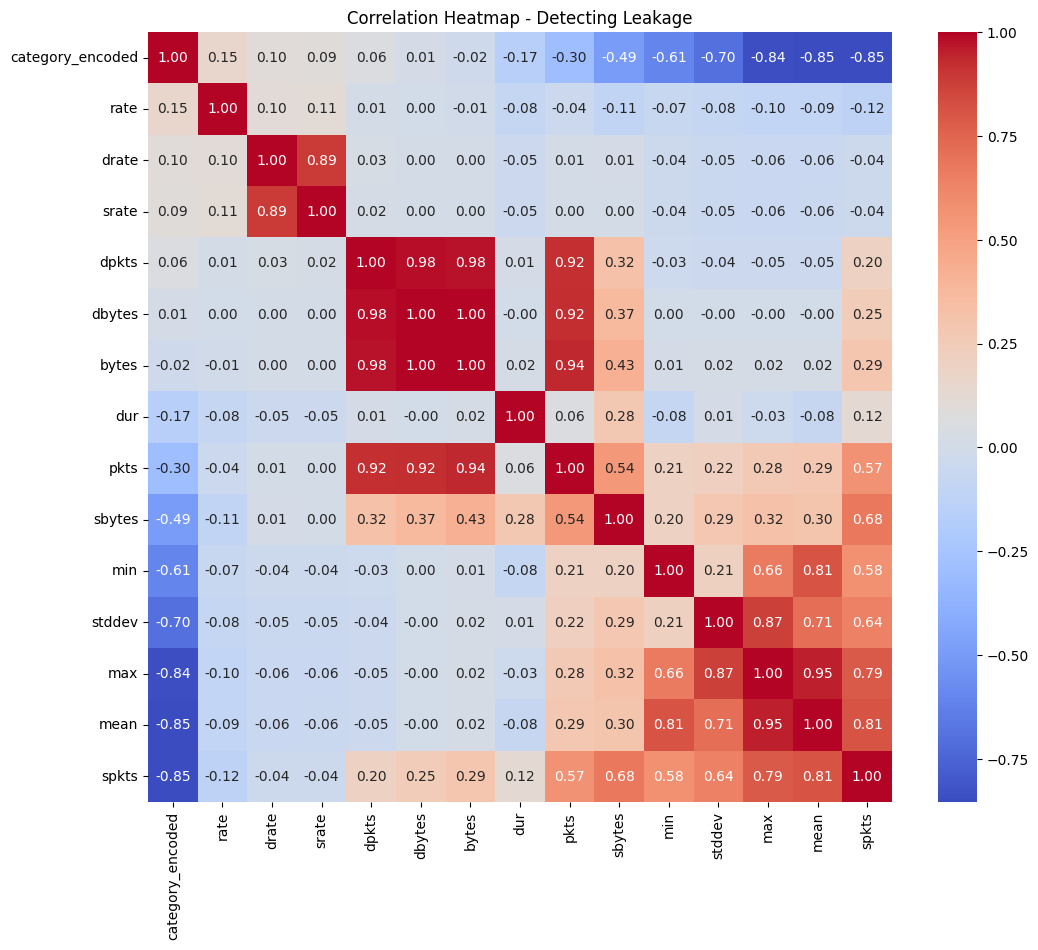

In [6]:
temp_df = df.copy()


le_temp = LabelEncoder()
temp_df['category_encoded'] = le_temp.fit_transform(temp_df['category'])


corr_matrix = temp_df.corr(numeric_only=True)
category_corr = corr_matrix['category_encoded'].sort_values(ascending=False)

print("--- Top Features Correlated with Category ---")
print(category_corr.head(15))

plt.figure(figsize=(12, 10))
top_features = category_corr.index[:15] # هناخد أعلى 15 ميزة بس للرسم
sns.heatmap(temp_df[top_features].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap - Detecting Leakage")
plt.show()

In [7]:
df=df.drop(['smac','dmac','sco','dco','saddr','soui','doui','daddr','attack','subcategory '],axis=1)

In [8]:
df.columns

Index(['flgs', 'proto', 'sport', 'dport', 'pkts', 'bytes', 'state', 'dur',
       'mean', 'stddev', 'sum', 'min', 'max', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'srate', 'drate', 'category'],
      dtype='object')

In [9]:
df.duplicated().sum()

np.int64(22178)

In [10]:
df=df.drop_duplicates()

In [11]:
df.isnull().sum()

flgs          0
proto         0
sport       208
dport       208
pkts          0
bytes         0
state         0
dur           0
mean          0
stddev        0
sum           0
min           0
max           0
spkts         0
dpkts         0
sbytes        0
dbytes        0
rate          0
srate         0
drate         0
category      0
dtype: int64

In [12]:
df=df.dropna(subset=['sport','dport'])

In [13]:
cols_to_convert = ['sport', 'dport']
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce').astype('Int64')

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1477614 entries, 0 to 1499999
Data columns (total 21 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   flgs      1477614 non-null  object 
 1   proto     1477614 non-null  object 
 2   sport     1475300 non-null  Int64  
 3   dport     1475299 non-null  Int64  
 4   pkts      1477614 non-null  int64  
 5   bytes     1477614 non-null  int64  
 6   state     1477614 non-null  object 
 7   dur       1477614 non-null  float64
 8   mean      1477614 non-null  float64
 9   stddev    1477614 non-null  float64
 10  sum       1477614 non-null  float64
 11  min       1477614 non-null  float64
 12  max       1477614 non-null  float64
 13  spkts     1477614 non-null  int64  
 14  dpkts     1477614 non-null  int64  
 15  sbytes    1477614 non-null  int64  
 16  dbytes    1477614 non-null  int64  
 17  rate      1477614 non-null  float64
 18  srate     1477614 non-null  float64
 19  drate     1477614 non-null

# Eda & Insights

Skew before transformation:

pkts: 330.1219
bytes: 381.5867
dur: 17.3083
mean: 0.7563
stddev: 1.0948
sum: 0.6725
min: 1.6955
max: 0.5552
spkts: 7.9595
dpkts: 420.5310
sbytes: 31.1291
dbytes: 389.9179
rate: 25.6151
srate: 75.3915
drate: 67.2959

Skew after transformation:

pkts: -0.0659
bytes: -0.6083
dur: -0.5395
mean: 0.7563
stddev: 0.8910
sum: 0.6725
min: 1.4235
max: 0.5552
spkts: -0.1274
dpkts: 0.9575
sbytes: -0.7366
dbytes: 0.2562
rate: 1.6943
srate: 7.1550
drate: 8.2446


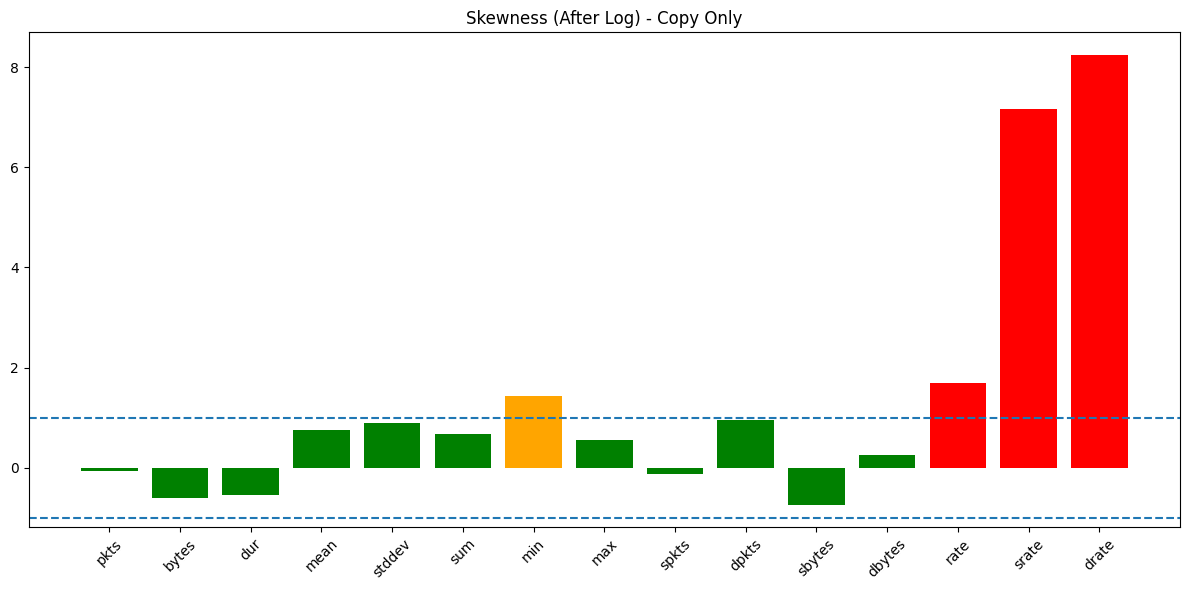

In [15]:
df_copy = df.copy()

num_cols = df_copy.select_dtypes(include='number')
num_cols = num_cols.drop(columns=['dport','sport'], errors='ignore')


skew_vals = num_cols.skew()
print("Skew before transformation:\n")
for col, skew_val in skew_vals.items():
    print(f"{col}: {skew_val:.4f}")

skewed_cols = skew_vals[abs(skew_vals) > 1].index

for col in skewed_cols:
    df_copy[col] = np.log1p(df_copy[col])

new_skew_vals = df_copy[num_cols.columns].skew()
print("\nSkew after transformation:\n")
for col, skew_val in new_skew_vals.items():
    print(f"{col}: {skew_val:.4f}")

skew_df = pd.DataFrame({
    'Column': new_skew_vals.index,
    'Skew': new_skew_vals.values
})

colors = []
for val in skew_df['Skew']:
    if abs(val) > 1.5:
        colors.append('red')
    elif abs(val) > 1:
        colors.append('orange')
    else:
        colors.append('green')

plt.figure(figsize=(12,6))
plt.bar(skew_df['Column'], skew_df['Skew'], color=colors)
plt.xticks(rotation=45)
plt.title('Skewness (After Log) - Copy Only')
plt.axhline(1, linestyle='--')
plt.axhline(-1, linestyle='--')
plt.tight_layout()
plt.show()

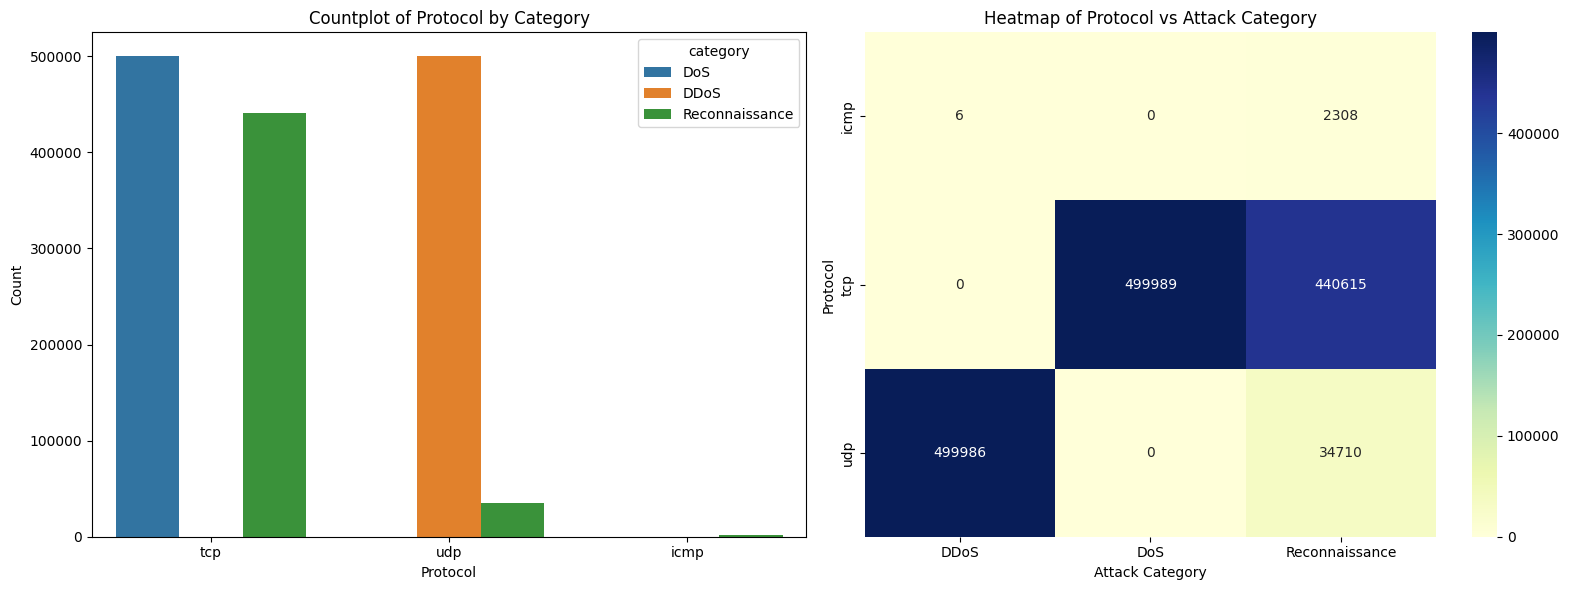

In [16]:
#the relationships between protocol type and attack category
plt.figure(figsize=(16,6))
plt.subplot(1, 2, 1)
sns.countplot(x='proto', hue='category', data=df_copy)
plt.title("Countplot of Protocol by Category")
plt.xlabel("Protocol")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
heatmap_data = pd.crosstab(df_copy['proto'], df_copy['category'])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu')
plt.ylabel("Protocol")
plt.xlabel("Attack Category")
plt.title("Heatmap of Protocol vs Attack Category")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


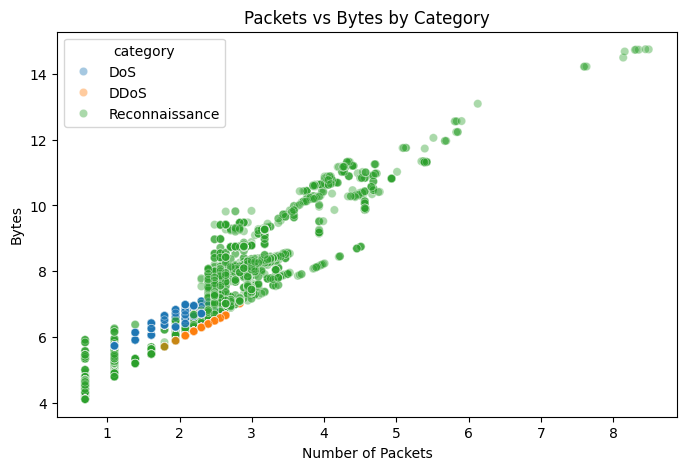

In [17]:
#لما عدد الباكتس وحجمهم كبر احتمالية حدوث الكونسينس كبيرة
plt.figure(figsize=(8,5))
sns.scatterplot(x='pkts', y='bytes', hue='category', data=df_copy, alpha=0.4)



plt.title("Packets vs Bytes by Category")
plt.xlabel("Number of Packets")
plt.ylabel("Bytes")
plt.show()



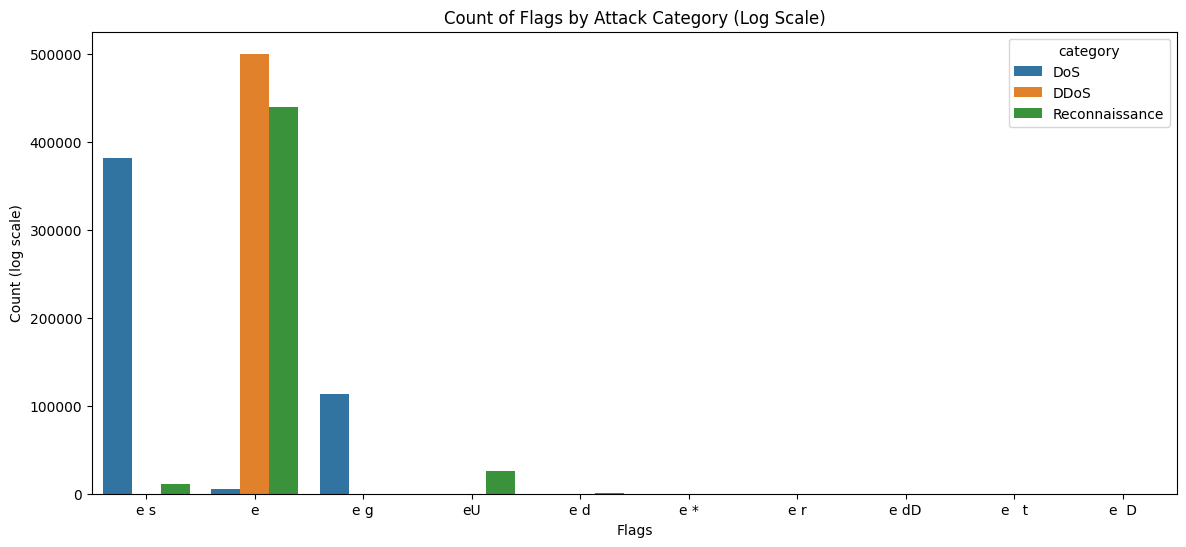

In [18]:
#relationships between flags and attack category
plt.figure(figsize=(14,6))
ax = sns.countplot(x='flgs', hue='category', data=df_copy)



plt.title("Count of Flags by Attack Category (Log Scale)") 
plt.xlabel("Flags")
plt.ylabel("Count (log scale)")
plt.show()

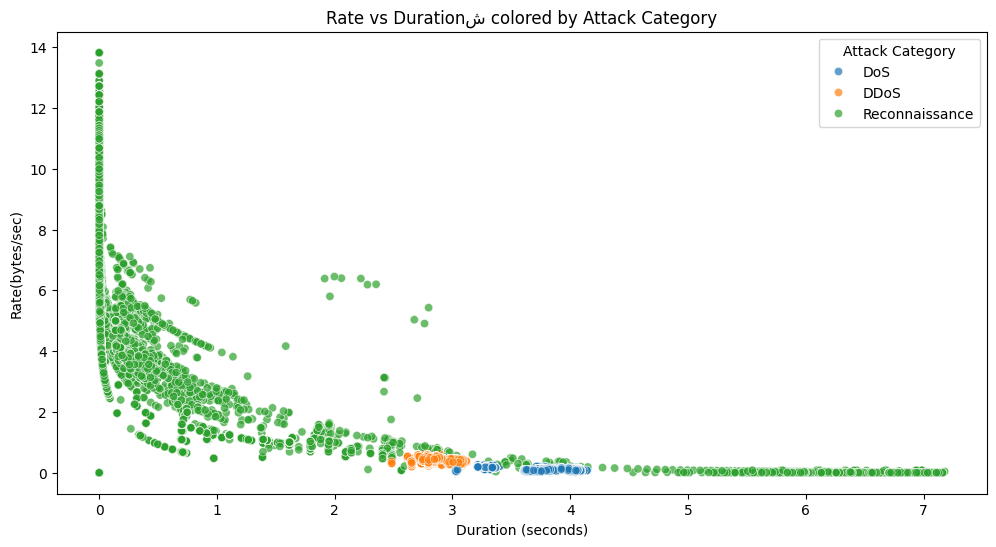

In [19]:
#الاكثر سرعة في ارسال البينانات ريكونسينس وكمان معدل ارساله مش ثابت
#على عكس ان dos , ddos بيكون وقتهم ثابت ايا كان نوع الهدف او المهمة
plt.figure(figsize=(12,6))
sns.scatterplot(x='dur', y='rate', hue='category', data=df_copy, alpha=0.7)
plt.title("Rate vs Durationش colored by Attack Category")
plt.xlabel("Duration (seconds)")
plt.ylabel("Rate(bytes/sec)")
plt.legend(title='Attack Category')
plt.show()

In [20]:
diff_bytes=abs(df_copy['sbytes'] - df_copy['dbytes'])

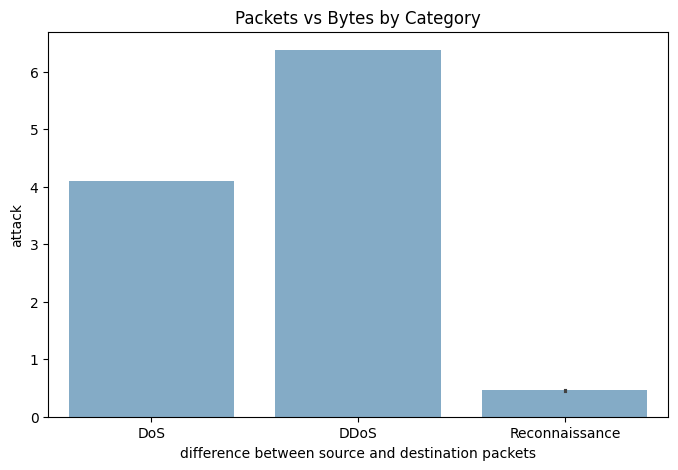

In [21]:
#بيتبعت باكتس كتيرة اوي من السورس اكتر من اللي لازم تستلمها المستقبلل ddos attack#
plt.figure(figsize=(8,5))
sns.barplot(x=df_copy['category'],y=diff_bytes, alpha=0.6)
plt.title('Packets vs Bytes by Category')
plt.xlabel('difference between source and destination packets')
plt.ylabel('attack')

plt.show()

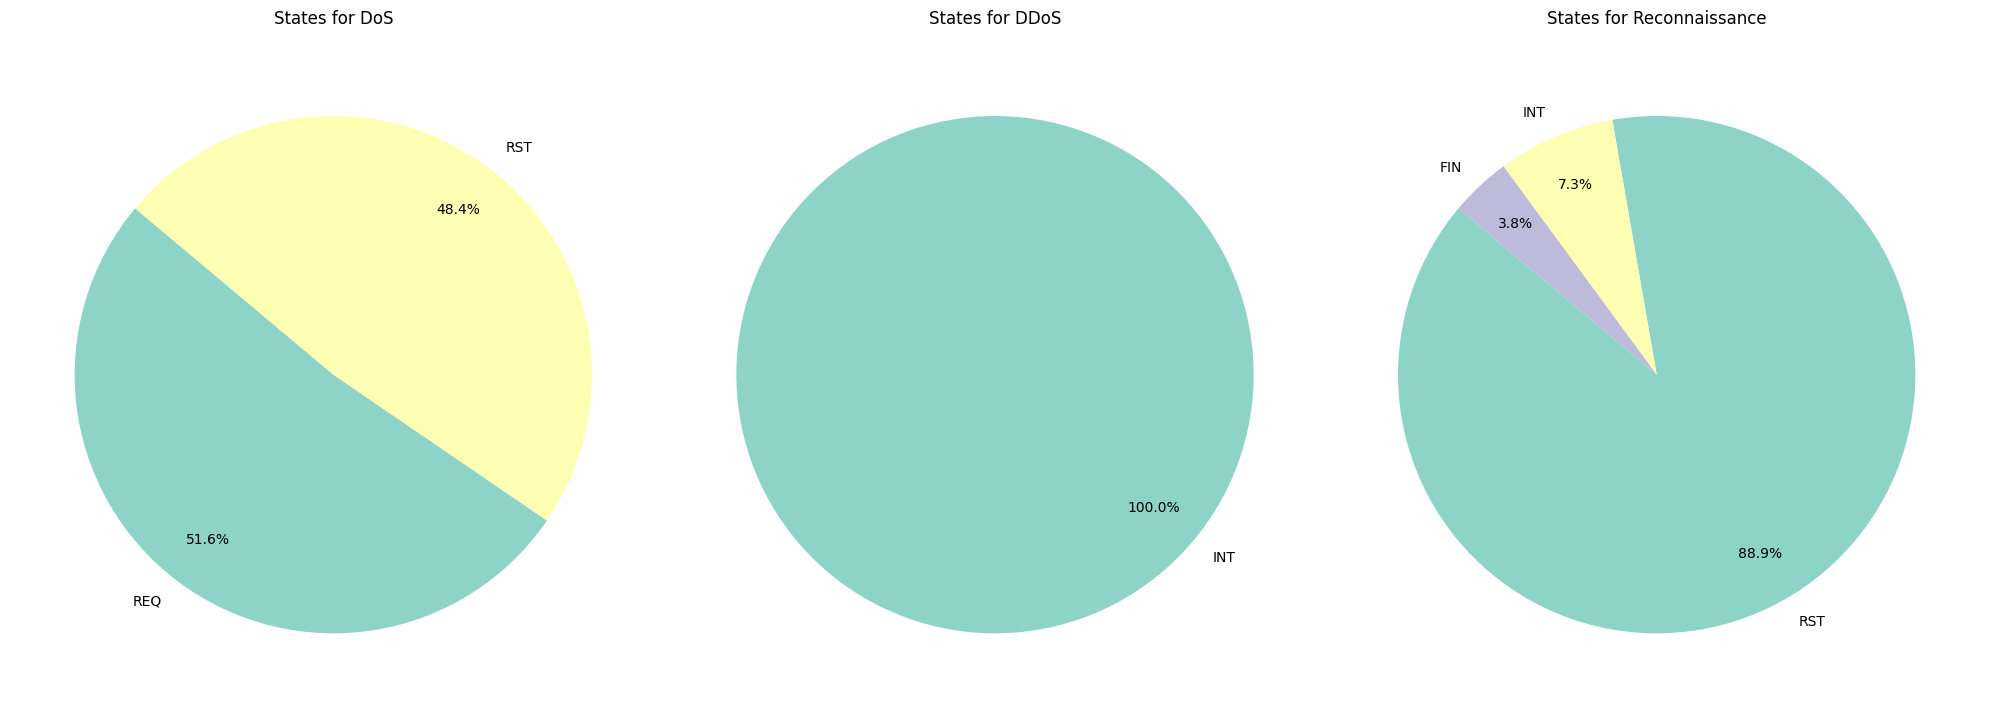

In [22]:
import matplotlib.pyplot as plt

categories = df_copy['category'].unique()

plt.figure(figsize=(20, 10))

for i, cat in enumerate(categories):
    plt.subplot(1, len(categories), i+1)

    state_counts = df_copy[df_copy['category'] == cat]['state'].value_counts()

    state_counts = state_counts[state_counts / state_counts.sum() > 0.01]

    colors = plt.cm.Set3.colors[:len(state_counts)]

    plt.pie(
        state_counts,
        labels=state_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        pctdistance=0.8,
        labeldistance=1.1,
        textprops={'fontsize': 10}
    )

    plt.title(f"States for {cat}", pad=20)

plt.tight_layout()
plt.show()

In [23]:
df=df.drop(['mean', 'max', 'stddev', 'min','dur', 'spkts', 'dpkts','dbytes', 'rate','sbytes','pkts'],axis=1)

In [24]:
df.head(20)

,flgs,proto,sport,dport,bytes,state,sum,srate,drate,category
0,e s,tcp,22766,80,676,RST,0.030697,0.053316,0.000000,DoS
1,e,udp,64782,80,780,INT,11.480439,0.724081,0.000000,DDoS
2,e g,tcp,37834,80,822,RST,0.425742,0.100801,0.040320,DoS
3,e,udp,1680,80,660,INT,11.305593,0.707418,0.000000,DDoS
4,e,udp,28004,80,600,INT,11.337292,0.577301,0.000000,DDoS
5,e,udp,41075,80,720,INT,13.634615,0.539878,0.000000,DDoS
6,e,udp,56501,80,660,INT,10.229549,0.653182,0.000000,DDoS
7,e s,tcp,26952,80,462,REQ,0.000000,0.049563,0.000000,DoS
8,e,udp,21525,80,600,INT,11.895568,0.431990,0.000000,DDoS
9,e,tcp,10527,8236,120,RST,0.000050,0.000000,0.000000,Reconnaissance


# Feature Engineering

In [25]:

def port_to_group(port):
    if 0 <= port <= 1023:
        return 'Well‑Known'
    elif 1024 <= port <= 49151:
        return 'Registered Ports'
    elif 49152 <= port <= 65535:
        return 'Dynamic / Private Ports'
    else:
        return 'Custom / Non‑standard'

df['dport'] =df['dport'].apply(port_to_group)
df['sport'] =df['sport'].apply(port_to_group)

print(df['dport'].head())
print(df['sport'].head())


0    Well‑Known
1    Well‑Known
2    Well‑Known
3    Well‑Known
4    Well‑Known
Name: dport, dtype: object
0           Registered Ports
1    Dynamic / Private Ports
2           Registered Ports
3           Registered Ports
4           Registered Ports
Name: sport, dtype: object


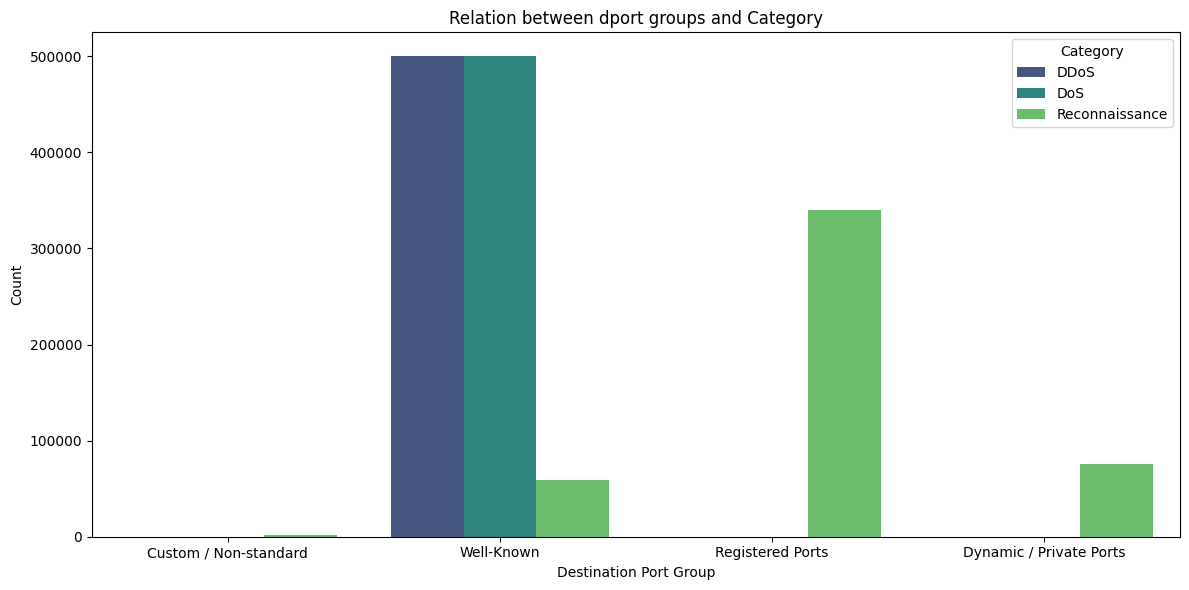

In [26]:
port_counts = df.groupby(['category', 'dport']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.barplot(data=port_counts, x='dport', y='count', hue='category', palette='viridis')
plt.title('Relation between dport groups and Category')
plt.xlabel('Destination Port Group')
plt.ylabel('Count')
plt.legend(title='Category')
plt.tight_layout()
plt.show()

In [27]:
x=df.drop('category' , axis=1)
y=df['category']

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8 , random_state=42)

In [29]:
x_train['flgs'].value_counts()

flgs
e        755308
e s      314925
e g       90674
eU        20900
e d         270
e *           7
e r           3
e   t         2
e dD          1
e  D          1
Name: count, dtype: int64

In [30]:
threshold = 1000


rare_states = x_train['state'].value_counts()[x_train['state'].value_counts() < threshold].index

x_train['state'] = x_train['state'].replace(rare_states, 'Other')
x_test['state'] = x_test['state'].replace(rare_states, 'Other')



rare_flgs = x_train['flgs'].value_counts()[x_train['flgs'].value_counts() < threshold].index

x_train['flgs'] = x_train['flgs'].replace(rare_flgs, 'Other')
x_test['flgs'] = x_test['flgs'].replace(rare_flgs, 'Other')

# Scaling

In [31]:
# نفس التقسيم
# 1. أعمدة الـ Log: اللي الانحراف فيها عالي جداً (فوق 1.0)
# دي اللي الـ Log نجح ينزلها من أرقام فلكية لأرقام معقولة
log_cols = ['srate', 'drate']

# 2. أعمدة الـ Power: اللي لسه "عنيدة" ومحتاجة ضغط إضافي (Yeo-Johnson)
# بما إن srate و drate لسه فوق الـ 7، الـ PowerTransformer هو اللي هينزلهم أكتر
power_cols = ['srate', 'drate'] 

# 3. أعمدة الـ Standard/Robust: اللي انحرافها أصلاً قليل (تحت 1.0)
# دي مش محتاجة Log، محتاجة بس Scaling عشان نوحد المدى (Range)
standard_cols = ['sum', 'bytes']

# ✅ نعمل copy عشان نحافظ على الأصل
x_train_processed = x_train.copy()
x_test_processed = x_test.copy()

# -----------------------------------
# 1. Log Transform (على الاتنين عادي)
# -----------------------------------
x_train_processed[log_cols] = np.log1p(x_train_processed[log_cols])
x_test_processed[log_cols] = np.log1p(x_test_processed[log_cols])

# -----------------------------------
# 2. PowerTransformer (fit على train فقط)
# -----------------------------------
pt = PowerTransformer(method='yeo-johnson')

x_train_processed[power_cols] = pt.fit_transform(x_train_processed[power_cols])
x_test_processed[power_cols] = pt.transform(x_test_processed[power_cols])

# -----------------------------------
# 3. StandardScaler (fit على train فقط)
# -----------------------------------
robust_scaler = RobustScaler()

cols_to_scale = log_cols + standard_cols

x_train_processed[cols_to_scale] = robust_scaler.fit_transform(x_train_processed[cols_to_scale])
x_test_processed[cols_to_scale] = robust_scaler.transform(x_test_processed[cols_to_scale])

# 4. Clip extreme values (مثلاً 1% و 99%)
for col in standard_cols:
    lower = x_train_processed[col].quantile(0.01)
    upper = x_train_processed[col].quantile(0.99)
    x_train_processed[col] = x_train_processed[col].clip(lower, upper)
    x_test_processed[col]  = x_test_processed[col].clip(lower, upper)

# Encoding

In [32]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [33]:
cat_cols = x_train_processed.select_dtypes(include='object').columns.tolist()


encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)


x_train_processed[cat_cols] = encoder.fit_transform(x_train_processed[cat_cols])


x_test_processed[cat_cols] = encoder.transform(x_test_processed[cat_cols])


print(x_train_processed.head())
print(x_train_processed.head())

         flgs  proto  sport  dport     bytes  state       sum     srate  \
1380816   2.0    1.0    1.0    3.0  0.411111    4.0  0.022607 -0.001592   
1436956   1.0    2.0    2.0    3.0  0.444444    1.0  1.057838  0.868918   
79416     3.0    1.0    2.0    3.0  0.140741    3.0 -0.004634 -0.031221   
78847     1.0    1.0    1.0    2.0 -0.777778    4.0 -0.003600 -0.319922   
1448708   2.0    1.0    2.0    3.0  0.522222    4.0  0.034193  0.063116   

            drate  
1380816  2.438035  
1436956  0.000000  
79416    0.000000  
78847    0.000000  
1448708  2.447947  
         flgs  proto  sport  dport     bytes  state       sum     srate  \
1380816   2.0    1.0    1.0    3.0  0.411111    4.0  0.022607 -0.001592   
1436956   1.0    2.0    2.0    3.0  0.444444    1.0  1.057838  0.868918   
79416     3.0    1.0    2.0    3.0  0.140741    3.0 -0.004634 -0.031221   
78847     1.0    1.0    1.0    2.0 -0.777778    4.0 -0.003600 -0.319922   
1448708   2.0    1.0    2.0    3.0  0.522222    4.0  0

In [34]:
import pandas as pd

#  حساب min و max لكل الأعمدة الرقمية في X_train_processed
numeric_cols_train = x_train_processed.select_dtypes(include='number')
range_train_df = pd.DataFrame({
    'min': numeric_cols_train.min(),
    'max': numeric_cols_train.max()
})
print("Range for X_train_processed:\n")
print(range_train_df)

#  نفس الشيء لـ X_test_processed
numeric_cols_test = x_test_processed.select_dtypes(include='number')
range_test_df = pd.DataFrame({
    'min': numeric_cols_test.min(),
    'max': numeric_cols_test.max()
})
print("\nRange for X_test_processed:\n")
print(range_test_df)

Range for X_train_processed:

            min       max
flgs   0.000000  4.000000
proto  0.000000  2.000000
sport  0.000000  3.000000
dport  0.000000  3.000000
bytes -0.888889  0.996296
state  0.000000  5.000000
sum   -0.004634  1.199621
srate -0.319922  1.268605
drate  0.000000  5.306989

Range for X_test_processed:

            min       max
flgs   0.000000  4.000000
proto  0.000000  2.000000
sport  0.000000  3.000000
dport  0.000000  3.000000
bytes -0.888889  0.996296
state  0.000000  5.000000
sum   -0.004634  1.199621
srate -0.319922  1.268487
drate  0.000000  5.306989


## Modling

1. Random Forest

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=30, 
    max_depth=3,        
    min_samples_leaf=30, 
    random_state=42, 
    n_jobs=-1
)
rf_model.fit(x_train_processed, y_train)

# التوقع
y_pred_test_rf = rf_model.predict(x_test_processed)
y_pred_train_rf= rf_model.predict(x_train_processed)

print(f"Train Accuracy For Random Forest: {accuracy_score(y_train, y_pred_train_rf):.4f}")
print(f"Test Accuracy For Random Forest: {accuracy_score(y_test, y_pred_test_rf):.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test_rf))

Train Accuracy For Random Forest: 0.9969
Test Accuracy For Random Forest: 0.9968

Classification Report (Test):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    100043
           1       0.99      1.00      1.00     99848
           2       1.00      0.99      0.99     95632

    accuracy                           1.00    295523
   macro avg       1.00      1.00      1.00    295523
weighted avg       1.00      1.00      1.00    295523



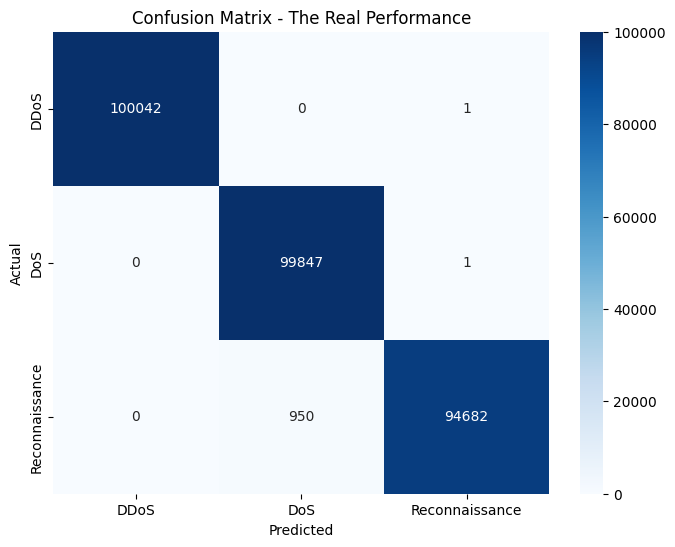

In [36]:
cm = confusion_matrix(y_test, y_pred_test_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - The Real Performance')
plt.show()

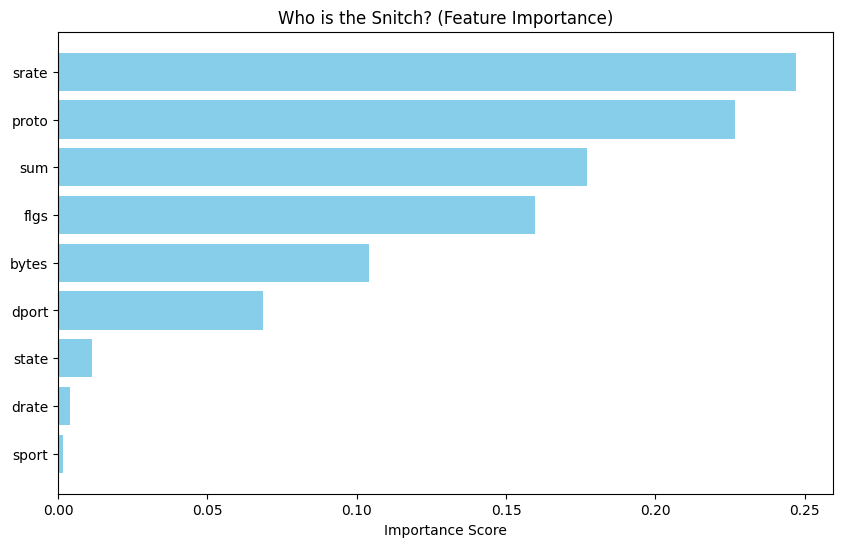

  Feature  Importance
7   srate    0.247054
1   proto    0.226543
6     sum    0.177021
0    flgs    0.159674
4   bytes    0.104253
3   dport    0.068760
5   state    0.011288
8   drate    0.003873
2   sport    0.001534


In [37]:
importances = rf_model.feature_importances_
feature_names = x_train_processed.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Who is the Snitch? (Feature Importance)')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance_df)

2. XGBoost

In [38]:
xgb_model = XGBClassifier(
    n_estimators=10,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_jobs=-1,
    random_state=42
)
xgb_model.fit(x_train_processed, y_train)

y_pred_xg_train = xgb_model.predict(x_train_processed)
y_pred_xg_test = xgb_model.predict(x_test_processed)

print(f"Train Accuracy For XGBoost: {accuracy_score(y_train, y_pred_xg_train):.4f}")
print(f"Test Accuracy For XGBoost: {accuracy_score(y_test, y_pred_xg_test):.4f}")
print("XGBoost Classification Report:")
print(classification_report(y_test, y_pred_xg_test))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [03:15:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Train Accuracy For XGBoost: 0.9972
Test Accuracy For XGBoost: 0.9971
XGBoost Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    100043
           1       0.99      1.00      1.00     99848
           2       1.00      0.99      1.00     95632

    accuracy                           1.00    295523
   macro avg       1.00      1.00      1.00    295523
weighted avg       1.00      1.00      1.00    295523



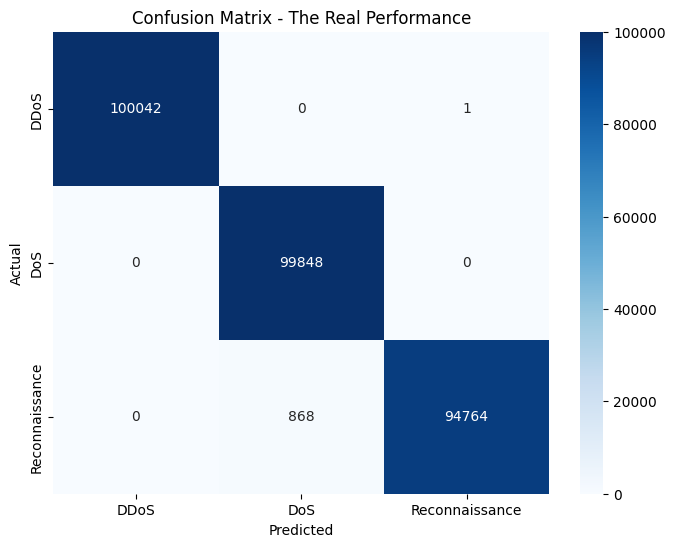

In [39]:
cm = confusion_matrix(y_test, y_pred_xg_test)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - The Real Performance')
plt.show()

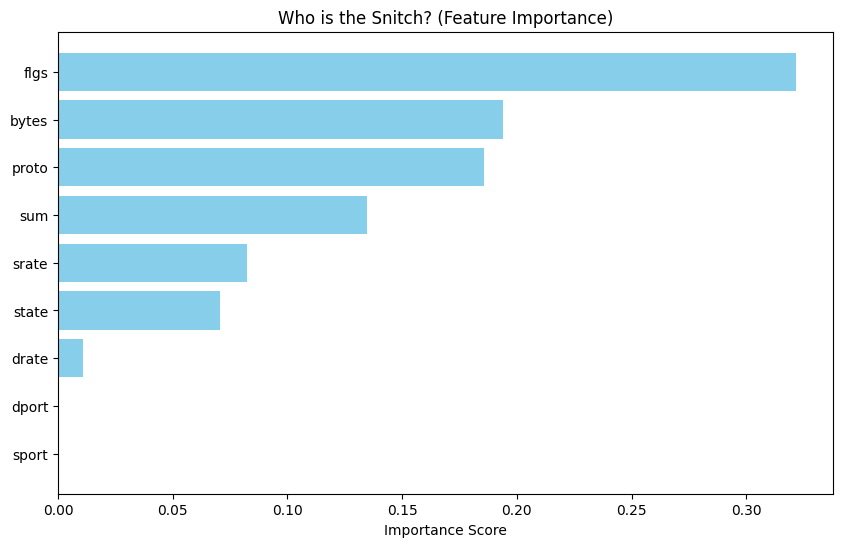

  Feature  Importance
0    flgs    0.321649
4   bytes    0.193894
1   proto    0.185654
6     sum    0.134858
7   srate    0.082418
5   state    0.070539
8   drate    0.010989
3   dport    0.000000
2   sport    0.000000


In [40]:
importances = xgb_model.feature_importances_
feature_names = x_train_processed.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)


plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Who is the Snitch? (Feature Importance)')
plt.gca().invert_yaxis()
plt.show()

print(feature_importance_df)